### Análisis de datos II
## MCA

En esta notebook se ejemplifica la técnica MCA sobre el dataset de [automóbiles](https://uci-ics-mlr-prod.aws.uci.edu/dataset/10/automobile).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

auto = pd.read_csv(
    '../datasets/automobile/imports-85.data',
    header=None,
    names=columns,
    na_values="?"
)

auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [3]:
auto = auto.dropna(subset=["price"])
auto = auto[auto["price"] != 0].reset_index(drop=True)

In [4]:
# Identificar tipos de variables
f_numericas = auto.select_dtypes(include="number").columns
f_categoricas = auto.select_dtypes(exclude="number").columns

In [5]:
f_categoricas

Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')

In [6]:
df_categorico = auto[f_categoricas] # df para trabajar solo con las categóricas
df_categorico.head(2)

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
0,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero,gas,std,two,convertible,rwd,front,dohc,four,mpfi


In [7]:
from mca import MCA

In [8]:
# Crear la matriz indicadora (one-hot encoding)
df_dummies = pd.get_dummies(df_categorico)
nombres_categorias = df_dummies.columns
nombres_categorias[:10]

Index(['make_alfa-romero', 'make_audi', 'make_bmw', 'make_chevrolet',
       'make_dodge', 'make_honda', 'make_isuzu', 'make_jaguar', 'make_mazda',
       'make_mercedes-benz'],
      dtype='object')

In [9]:
# Aplicar MCA
mca_model = MCA(df_dummies, benzecri=True) # benzecri=True: aplicar corrección de Benzécri

# Obtener la inercia explicada corregida
inercia_explicada = mca_model.expl_var()

In [10]:
# Obtener las coordenadas de las categorías
col_coords = mca_model.fs_c(N=2)

# y las coordenadas de las observaciones
row_coords = mca_model.fs_r(N=2)

---
### Mapa de categorías

Elijo algunas. Plotear todas nos da un plot ilegible!

In [11]:
# https://matplotlib.org/stable/api/markers_api.html

markers = {
    "make": "o",             # círculo
    "fuel-type": "s",        # cuadrado
    "aspiration": "^",       # triángulo arriba
    "num-of-doors": "D",     # diamante
    "body-style": "P",       # + relleno
    "drive-wheels": "X",     # X rellena
    "engine-location": "v",  # triángulo abajo
    "engine-type": "*",      # estrella
    "num-of-cylinders": "<", # triángulo izquierda
    "fuel-system": ">",      # triángulo derecha
}

In [12]:
# selección de variables para el plot
variables_to_plot = [
    "fuel-type",
    "num-of-doors",
    "body-style",
    "drive-wheels"
]

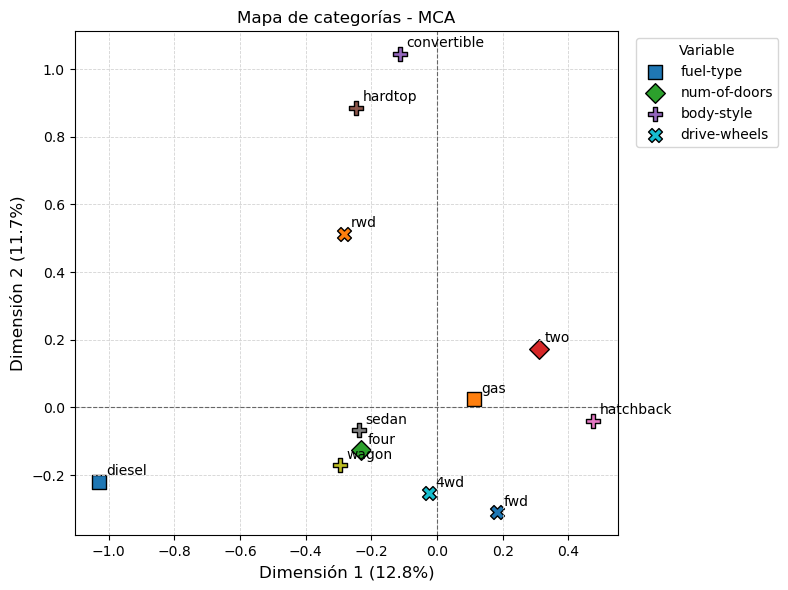

In [13]:
plt.figure(figsize=(8, 6))

# Para no repetir variables en la leyenda
variables_graficadas = set()

for i, label in enumerate(df_dummies.columns):
    
    variable = label.rsplit("_", 1)[0]
    if variable not in variables_to_plot:
        continue
    categoria = label.split("_", 1)[1]
        
    if variable not in variables_graficadas:
        nombre_leyenda = variable
        variables_graficadas.add(variable)
    else:
        nombre_leyenda = None
        
    plt.scatter(
        col_coords[i, 0],
        col_coords[i, 1],
        marker=markers[variable],
        s=100,
        edgecolor="black",
        label=nombre_leyenda
    )

    plt.text(
        col_coords[i, 0] + 0.02,
        col_coords[i, 1] + 0.02,
        categoria,
        fontsize=10
    )

plt.axhline(0, color="#666666", linestyle="--", linewidth=0.8)
plt.axvline(0, color="#666666", linestyle="--", linewidth=0.8)
plt.grid(color='lightgray', ls='--', linewidth=0.6)

plt.xlabel(f"Dimensión 1 ({inercia_explicada[0]*100:.1f}%)", fontsize=12)
plt.ylabel(f"Dimensión 2 ({inercia_explicada[1]*100:.1f}%)", fontsize=12)

plt.title("Mapa de categorías - MCA")

plt.legend(
    title="Variable",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

**Algunos insights**
- Las categorías sedan, four (cuatro puertas) y wagon (familiar) están muy agrupados cerca del centro. Esto nos indica que en el dataset hay una fuerte asociación  entre estas categorías de vehículo.

- Los convertibles están muy alejados del centro. Su proximidad con rwd nos muestra que los autos descapotables tienden fuertemente a asociarse con la tracción trasera (rear-wheel drive).
- Los diesel están muy alejados de todo lo demás. Estos autos tienen un perfil categórico poco común.

---
### Mapa de individuos

Le doy color según una de las categorías. En este ejemplo, tipo de combustible (`fuel-type`).

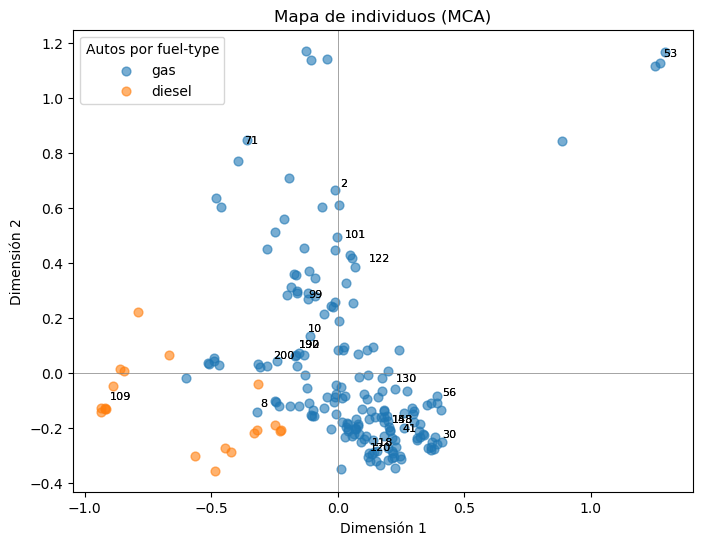

In [14]:
# Elige índices aleatorios para marcarlos en el plot
indices_random = np.random.choice(
    len(row_coords),
    size=20,
    replace=False
)

x = row_coords[:,0] + np.random.normal(0, 0.02, len(row_coords))
y = row_coords[:,1] + np.random.normal(0, 0.02, len(row_coords))

plt.figure(figsize=(8,6))

for fueltype in df_categorico["fuel-type"].unique():
    mask = df_categorico["fuel-type"] == fueltype

    plt.scatter(
        x[mask],
        y[mask],
        alpha=0.6,
        s=40,
        label=fueltype
    )
    
    for i in indices_random:
        plt.text(row_coords[i, 0] + 0.02,
                 row_coords[i, 1] + 0.02,
                 str(df_categorico.index[i]),
                 fontsize=8
                )

plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)

plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.title("Mapa de individuos (MCA)")
plt.legend(title="Autos por fuel-type")
plt.show()

**Interpretación**

- Todos los autos están bien separados según el tipo de combustible. Esto significa que esta es una variable estructural muy fuerte y marca una diferencia notoria en el perfil de los vehículos.

- Los puntos azules, que representan a los autos a gas, están muy dispersos a lo largo del eje 2. Esto significa que los autos a gas tienen una gran variedad de perfiles (formas, tamaños, motores, etc.)
Por otro lado, los diesel forman un grupo más compacto y homogéneo.

- Los índices nos permiten hacer zoom y explorar filas específicas del dataset.

In [15]:
df_categorico.iloc[111]

make                peugot
fuel-type           diesel
aspiration           turbo
num-of-doors          four
body-style           wagon
drive-wheels           rwd
engine-location      front
engine-type              l
num-of-cylinders      four
fuel-system            idi
Name: 111, dtype: object

In [16]:
auto.iloc[111]

symboling                  0
normalized-losses        NaN
make                  peugot
fuel-type             diesel
aspiration             turbo
num-of-doors            four
body-style             wagon
drive-wheels             rwd
engine-location        front
wheel-base             114.2
length                 198.9
width                   68.4
height                  58.7
curb-weight             3485
engine-type                l
num-of-cylinders        four
engine-size              152
fuel-system              idi
bore                     3.7
stroke                  3.52
compression-ratio       21.0
horsepower              95.0
peak-rpm              4150.0
city-mpg                  25
highway-mpg               25
price                17075.0
Name: 111, dtype: object

---
### Biplot

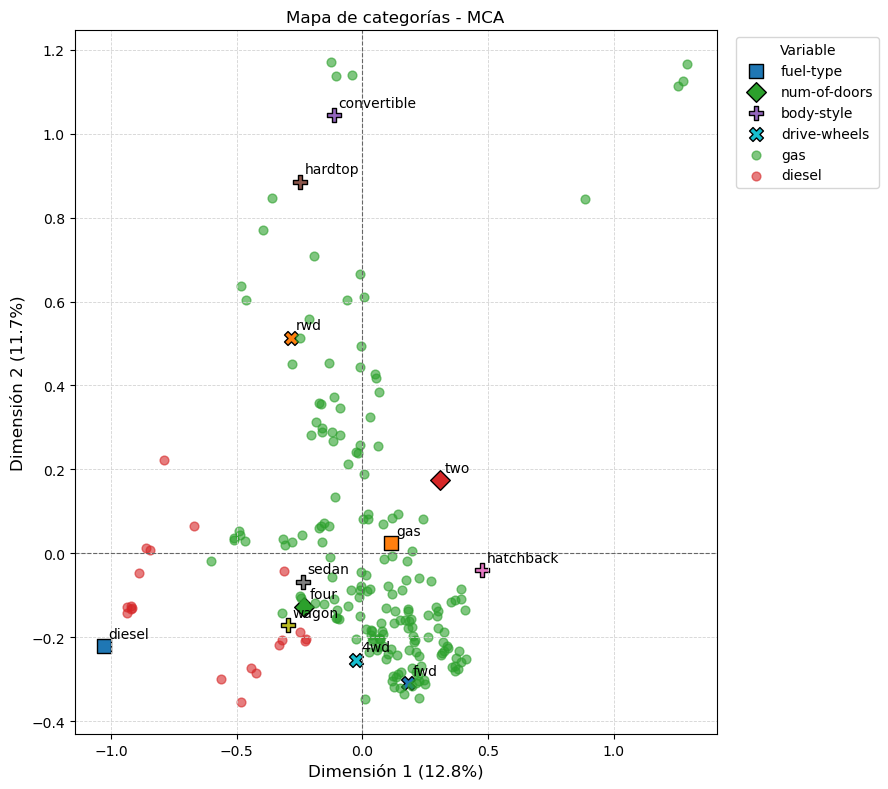

In [17]:
plt.figure(figsize=(9, 8))

# Para no repetir variables en la leyenda
variables_graficadas = set()

# CATEGORIAS ------------------------------------------------------
for i, label in enumerate(df_dummies.columns):
    
    variable = label.rsplit("_", 1)[0]
    if variable not in variables_to_plot:
        continue
    # Nombre de la categoría
    categoria = label.split("_", 1)[1]
        
    # Agregar label solo la primera vez que aparece cada variable
    if variable not in variables_graficadas:
        nombre_leyenda = variable
        variables_graficadas.add(variable)
    else:
        nombre_leyenda = None
        
    plt.scatter(
        col_coords[i, 0],
        col_coords[i, 1],
        marker=markers[variable],
        s=100,
        edgecolor="black",
        label=nombre_leyenda
    )

    # Nombre de la categoría
    plt.text(
        col_coords[i, 0] + 0.02,
        col_coords[i, 1] + 0.02,
        categoria,
        fontsize=10
    )

# INDIVIDUOS ----------------------------------------------------    
for fueltype in df_categorico["fuel-type"].unique():
    mask = df_categorico["fuel-type"] == fueltype

    plt.scatter(
        x[mask],
        y[mask],
        alpha=0.6,
        s=40,
        label=fueltype
    )


plt.axhline(0, color="#666666", linestyle="--", linewidth=0.8)
plt.axvline(0, color="#666666", linestyle="--", linewidth=0.8)
plt.grid(color='lightgray', ls='--', linewidth=0.6)

plt.xlabel(f"Dimensión 1 ({inercia_explicada[0]*100:.1f}%)", fontsize=12)
plt.ylabel(f"Dimensión 2 ({inercia_explicada[1]*100:.1f}%)", fontsize=12)

plt.title("Mapa de categorías - MCA")

plt.legend(
    title="Variable",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

Cuando juntamos todo en un solo mapa, no solo vemos las etiquetas, sino a los autos reales dentro de su espacio de 'conceptos' o categorías.

No solo vemos dónde vive una categoría (por ejemplo 'convertible'), sino cuántos autos (individuos) habitan esa zona. Es una medida de la concentración real de datos detrás de cada etiqueta.